<a href="https://colab.research.google.com/github/marceloirineu/Data_Driven_Science_Python/blob/master/7_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aula 7 - Construção de Circuitos Quânticos com IBM Qiskit (Parte 1 e 2)**

Neste collab, você encontrara os algoritmos de Deutsch e Deutsch-Josza aplicados aos oraculos mostrados nos exercicios em aula. Em seguida, tera a resolução do exercicio sobre a construção de estados GHZ.

In [ ]:
!pip install qiskit qiskit-aer pylatexenc qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.2 MB/s eta 0:00:00
  Created wh

# Algoritmo de Deutsch.

O algoritmo de Deutsch tem como função descobrir se uma função booleana $f:\{0,1\}\rightarrow\{0,1\}$ é constante ou balanceada, isto é:
\begin{equation}
f(0)= f(1),
\end{equation}
se for constante, ou
\begin{equation}
f(0)\neq f(1),
\end{equation}
se for balanceada. Como exemplo, aplicaremos o oráculo mostrado no exercício 1.

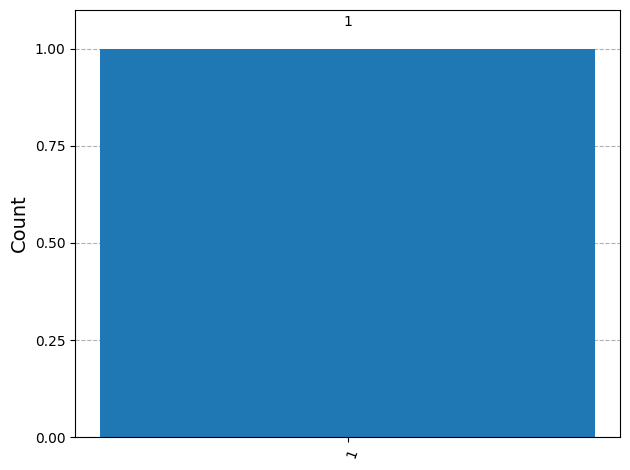

In [ ]:
# ==========================================================
#  CONFIGURAÇÃO
# ==========================================================
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
# Construção do Oráculo
oracle_qc = QuantumCircuit(1, name="O")
# Define o oráculo por portas lógicas
oracle_qc.z(0)
# Define o circuito de oráculo como porta customizável
oracle_gate = oracle_qc.to_gate()

# ==========================================================
# 1. ALGORITMO
# ==========================================================
# Define os registros quânticos
qubits = QuantumRegister(1, 'qubits')
# Define o registro clássico
bits = ClassicalRegister(1, 'bits')
# Define o circuito quântico
qc = QuantumCircuit(qubits, bits)

# 1) Aplica a Hadamard
qc.h(qubits)
qc.barrier()

# 2) Aplica o Oráculo
qc.append(oracle_gate, qubits)
qc.barrier()

# 3) Aplica a Hadamard
qc.h(qubits)
qc.barrier()

# Final) Medição
qc.measure(qubits, bits)

# Opcional) Mostrar o circuito como um desenho. mlp -> Matplotlib
#display(qc.draw('mpl'))
# Mostra o circuito com o oraculo exposto
#display(qc.decompose().draw('mpl'))

# ==========================================================
# 2. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=1)
result = job.result()
counts = result[0].data["bits"].get_counts()
plot_histogram(counts)


# Algoritmo de Deutsch-Josza.

O algortimo de Deutsch-Josza tem como função descobrir se uma função booleana $f:\{0,1\}^{n}\rightarrow\{0,1\}$ é constante ou balanceada. No caso da função constante, para todas as entradas da função, temos a mesma saída $0$ ou $1$. Já no caso da função balanceada, para metade das entradas a saída é $0$ e para a outra metade é $1$. Como exemplo, aplicaremos o oráculo mostrado no exercício 2.

In [ ]:
# ==========================================================
#  CONFIGURAÇÃO
# ==========================================================
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
n = 4  # Número de qubits de dados
# Construção do Oráculo
oracle_qc = QuantumCircuit(n, name="O")
# Define o oráculo por portas lógicas
oracle_qc.z(0)
oracle_qc.z(1)
oracle_qc.z(2)
oracle_qc.z(3)
# Define o circuito de oráculo como porta customizável
oracle_gate = oracle_qc.to_gate()

# ==========================================================
# 1. ALGORITMO
# ==========================================================
# Define os registros quânticos
qubits = QuantumRegister(n, 'qubits')
# Define o registro clássico
bits = ClassicalRegister(n, 'bits')

# Define o circuito quântico
qc = QuantumCircuit(qubits, bits)

# 2) Aplica a Hadamard
qc.h(qubits)
qc.barrier()

# 3) Aplica o Oráculo
qc.append(oracle_gate, qubits)
qc.barrier()

# 4) Aplica a Hadamard
qc.h(qubits)
qc.barrier()

# Final) Medição
qc.measure(qubits, bits)

# Opcional) Mostrar o circuito
#display(qc.draw('mpl'))
# Mostra o circuito com o oraculo exposto
#display(qc.decompose().draw('mpl'))

# ==========================================================
# 2. EXECUÇÃO
# ==========================================================
from qiskit_aer import AerSimulator
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=1)
result = job.result()
counts = result[0].data["bits"].get_counts()
plot_histogram(counts)

# Exercicío 3: Estado GHZ

In [ ]:
# ==========================================================
# 1. CIRCUITO GHZ (Para 3 qubits)
# ==========================================================
from qiskit import QuantumCircuit
qc = QuantumCircuit(3)

# 1) Aplica a primeira Hadamard sobre o primeiro qubit
qc.h(0)

# 2) Aplica a primeira CNOT
qc.cx(0, 1)

# 3) Aplica a segunda CNOT
qc.cx(1, 2)

# (Opcional) Mostrar o circuito
#display(qc.draw('mpl'))

# Final) Geração grafico do estado GHZ
from qiskit.quantum_info import Statevector
sv = Statevector.from_instruction(qc)
sv.draw('latex')

<IPython.core.display.Latex object>

In [ ]:
# ==========================================================
# 1. CIRCUITO GHZ (Para n qubits)
# ==========================================================
from qiskit import QuantumCircuit
n = 5 # Numero de qubits
qc = QuantumCircuit(n)

# 1) Aplica a primeira Hadamard sobre o primeiro qubit
qc.h(0)

# 2) Aplicação de CNOTS em sequência
for i in range(n - 1):
    qc.cx(i, i + 1)

# (Opcional) Mostrar o circuito
#display(qc.draw('mpl'))

# Final) Geração grafico do estado GHZ
from qiskit.quantum_info import Statevector
sv = Statevector.from_instruction(qc)
sv.draw('latex')

<IPython.core.display.Latex object>